In [1]:
import pandas as pd
import numpy as np
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import os
import json 

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
import pandas as pd

path = '/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/Data_Split/' 

# โหลดไฟล์
X_train = pd.read_csv(f'{path}X_train_80.csv')
X_test = pd.read_csv(f'{path}X_test_20.csv')
y_train = pd.read_csv(f'{path}y_train_80.csv').squeeze()
y_test = pd.read_csv(f'{path}y_test_20.csv').squeeze()

print("✅ โหลดชุดข้อมูล 80:20 เรียบร้อย!")
print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

✅ โหลดชุดข้อมูล 80:20 เรียบร้อย!
Train shape: (8000, 20)
Test shape: (2000, 20)


------------------------------
Baseline Model: Multi-Layer Perceptron (MLP)
------------------------------

------------------------------
Performing 5-Fold Cross-Validation...
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 1: 0.8000  (80.00%)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 2: 0.8000  (80.00%)


...

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 4: 0.8000  (80.00%)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 5: 0.8000  (80.00%)
------------------------------
>> Average CV Accuracy: 0.8000 (± 0.0000)
------------------------------

✓ Selected Best Model from Fold 1 (Accuracy: 0.8000)

TEST SET PERFORMANCE
Accuracy:  0.8000
Precision: 0.0000
Recall:    0.0000
F1-Score:  0.0000
ROC-AUC:   0.4711

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.80      1.00      0.89      1600
     Disease       0.00      0.00      0.00       400

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.44      2000
weighted avg       0.64      0.80      0.71      2000



/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to con

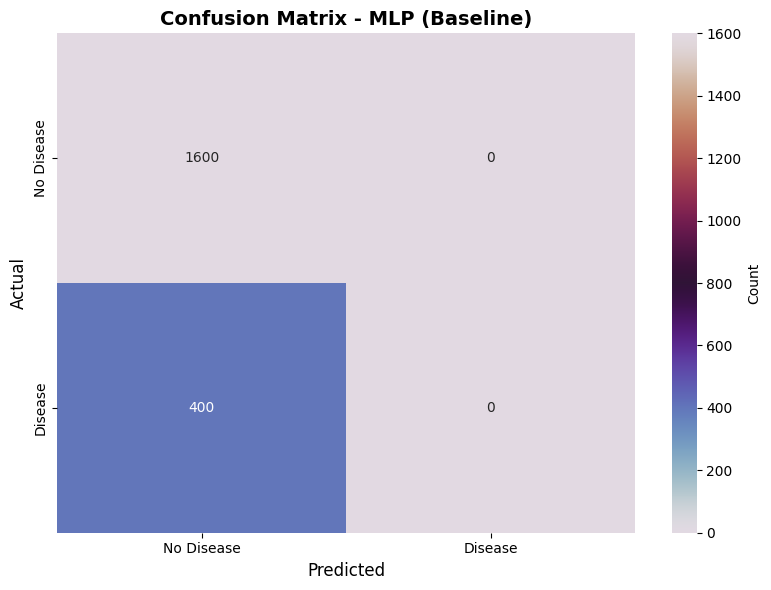


BASELINE RESULTS SUMMARY
Model               : MLP
Sampling            : None (Baseline)
CV_Accuracy         : 0.8000
CV_Std              : 0.0000
Best_Fold           : 1
Best_Fold_Val_Acc   : 0.8000
Test_Accuracy       : 0.8000
Precision           : 0.0000
Recall              : 0.0000
F1_Score            : 0.0000
ROC_AUC             : 0.4711
✓ Saved best fold model: mlp/models/MLP_baseline_bestfold.h5


In [3]:

print("-" * 30)
print('Baseline Model: Multi-Layer Perceptron (MLP)')
print("-" * 30)

# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Build MLP model
def create_mlp_model(input_dim):
    model = Sequential([
        # Input Layer
        Dense(256, activation='relu', input_dim=input_dim),
        BatchNormalization(),
        Dropout(0.4),
        
        # Hidden Layer 1
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        
        # Hidden Layer 2
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        
        # Hidden Layer 3
        Dense(32, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        
        # Hidden Layer 4
        Dense(16, activation='relu'),
        Dropout(0.2),
        
        # Output Layer
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall(), tf.keras.metrics.AUC()]
    )
    
    return model

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

# Cross-validation - Train and find best fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
cv_models = []

print("\n" + "-" * 30)
print("Performing 5-Fold Cross-Validation...")
print("-" * 30)

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel())):
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    # Create and train model for this fold
    model_fold = create_mlp_model(X_train.shape[1])
    model_fold.fit(
        X_train_fold, y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        epochs=100,
        batch_size=32,
        callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
        verbose=0
    )
    
    # Evaluate
    _, accuracy, _, _, _ = model_fold.evaluate(X_val_fold, y_val_fold, verbose=0)
    cv_scores.append(accuracy)
    cv_models.append(model_fold)
    print(f"Fold {fold+1}: {accuracy:.4f}  ({accuracy*100:.2f}%)")

print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print("-" * 30)

# Select best model from CV
best_fold_idx = np.argmax(cv_scores)
mlp_baseline = cv_models[best_fold_idx]
print(f"\n✓ Selected Best Model from Fold {best_fold_idx+1} (Accuracy: {cv_scores[best_fold_idx]:.4f})")

# Predictions on test set using best CV model
y_pred_proba = mlp_baseline.predict(X_test, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# Test set performance
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n" + "=" * 50)
print("TEST SET PERFORMANCE")
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("=" * 50)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='twilight', 
            xticklabels=['No Disease', 'Disease'], 
            yticklabels=['No Disease', 'Disease'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - MLP (Baseline)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary dictionary
mlp_baseline_results = {
    'Model': 'MLP',
    'Sampling': 'None (Baseline)',
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Best_Fold': best_fold_idx + 1,
    'Best_Fold_Val_Acc': cv_scores[best_fold_idx],
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc
}

print("\n" + "=" * 50)
print("BASELINE RESULTS SUMMARY")
print("=" * 50)
for key, value in mlp_baseline_results.items():
    if isinstance(value, float):
        print(f"{key:20s}: {value:.4f}")
    else:
        print(f"{key:20s}: {value}")
print("=" * 50)

# Create directory
os.makedirs('mlp/models', exist_ok=True)

# Save best fold model
mlp_baseline.save('mlp/models/MLP_baseline_bestfold.h5')
print(f"✓ Saved best fold model: mlp/models/MLP_baseline_bestfold.h5")


------------------------------
MLP + SMOTE
------------------------------
Original training set size: 8000
After SMOTE training set size: 12800
Original class distribution: {0: np.int64(6400), 1: np.int64(1600)}
After SMOTE class distribution: {0: np.int64(6400), 1: np.int64(6400)}
------------------------------

------------------------------
Training MLP with SMOTE...
------------------------------

------------------------------
Performing 5-Fold Cross-Validation with SMOTE...
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This f

Fold 1: 0.5612  (56.12%)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 2: 0.3481  (34.81%)


...

Fold 3: 0.5938  (59.38%)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 4: 0.3738  (37.38%)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 5: 0.6619  (66.19%)
------------------------------
>> Average CV Accuracy: 0.5077 (± 0.1245)
------------------------------

✓ Selected Best Model from Fold 5 (Accuracy: 0.6619)

TEST SET PERFORMANCE (SMOTE)
Accuracy:  0.6550
Precision: 0.1967
Recall:    0.2350
F1-Score:  0.2141
ROC-AUC:   0.5052

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.80      0.76      0.78      1600
     Disease       0.20      0.23      0.21       400

    accuracy                           0.66      2000
   macro avg       0.50      0.50      0.50      2000
weighted avg       0.68      0.66      0.67      2000



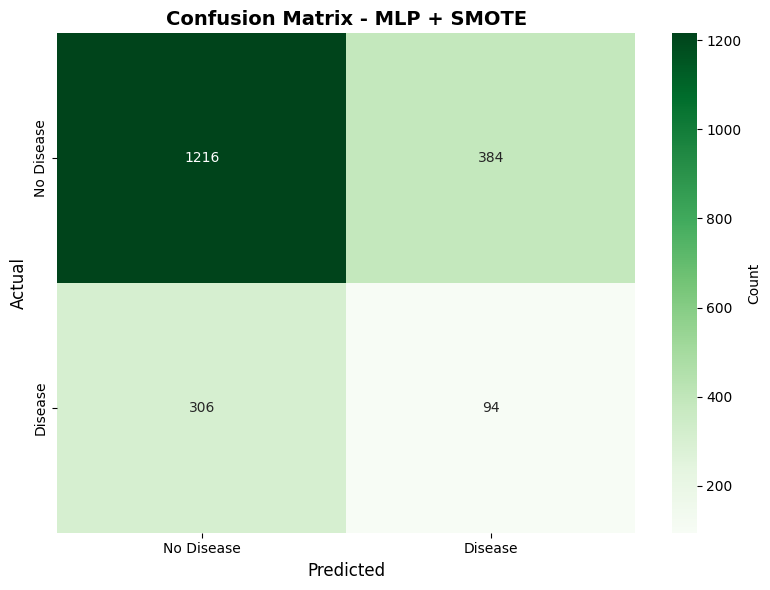


SMOTE RESULTS SUMMARY
Model               : MLP
Sampling            : SMOTE
CV_Accuracy         : 0.5077
CV_Std              : 0.1245
Best_Fold           : 5
Best_Fold_Val_Acc   : 0.6619
Test_Accuracy       : 0.6550
Precision           : 0.1967
Recall              : 0.2350
F1_Score            : 0.2141
ROC_AUC             : 0.5052
✓ Saved best fold model: mlp/models/MLP_smote_bestfold.h5
✓ Saved: mlp/models/smote_sampler_mlp.pkl


In [4]:
from imblearn.over_sampling import SMOTE

print("-" * 30)
print('MLP + SMOTE')
print("-" * 30)

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to training data
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train.values.ravel())

print(f"Original training set size: {len(X_train)}")
print(f"After SMOTE training set size: {len(X_train_smote)}")
print(f"Original class distribution: {dict(pd.Series(y_train.values.ravel()).value_counts())}")
print(f"After SMOTE class distribution: {dict(pd.Series(y_train_smote).value_counts())}")
print("-" * 30)

# Create model
mlp_smote = create_mlp_model(X_train.shape[1])

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

print("\n" + "-" * 30)
print("Training MLP with SMOTE...")
print("-" * 30)

# Cross-validation with SMOTE
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
cv_models = []

print("\n" + "-" * 30)
print("Performing 5-Fold Cross-Validation with SMOTE...")
print("-" * 30)

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel())):
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    # Apply SMOTE
    X_train_fold_smote, y_train_fold_smote = smote.fit_resample(X_train_fold, y_train_fold)
    
    # Create and train model
    model_fold = create_mlp_model(X_train.shape[1])
    model_fold.fit(
        X_train_fold_smote, y_train_fold_smote,
        validation_data=(X_val_fold, y_val_fold),
        epochs=100,
        batch_size=32,
        callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
        verbose=0
    )
    
    # Evaluate
    _, accuracy, _, _, _ = model_fold.evaluate(X_val_fold, y_val_fold, verbose=0)
    cv_scores.append(accuracy)
    cv_models.append(model_fold)
    print(f"Fold {fold+1}: {accuracy:.4f}  ({accuracy*100:.2f}%)")

print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print("-" * 30)

# Select best model from CV
best_fold_idx = np.argmax(cv_scores)
mlp_smote = cv_models[best_fold_idx]
print(f"\n✓ Selected Best Model from Fold {best_fold_idx+1} (Accuracy: {cv_scores[best_fold_idx]:.4f})")

# Predictions using best CV model
y_pred_proba = mlp_smote.predict(X_test, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# Test set performance
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n" + "=" * 50)
print("TEST SET PERFORMANCE (SMOTE)")
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("=" * 50)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['No Disease', 'Disease'], 
            yticklabels=['No Disease', 'Disease'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - MLP + SMOTE', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary dictionary
mlp_smote_results = {
    'Model': 'MLP',
    'Sampling': 'SMOTE',
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Best_Fold': best_fold_idx + 1,
    'Best_Fold_Val_Acc': cv_scores[best_fold_idx],
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc
}

print("\n" + "=" * 50)
print("SMOTE RESULTS SUMMARY")
print("=" * 50)
for key, value in mlp_smote_results.items():
    if isinstance(value, float):
        print(f"{key:20s}: {value:.4f}")
    else:
        print(f"{key:20s}: {value}")
print("=" * 50)

# Save best fold model
mlp_smote.save('mlp/models/MLP_smote_bestfold.h5')
joblib.dump(smote, 'mlp/models/smote_sampler_mlp.pkl')
print(f"✓ Saved best fold model: mlp/models/MLP_smote_bestfold.h5")
print("✓ Saved: mlp/models/smote_sampler_mlp.pkl")

------------------------------
MLP + ADASYN
------------------------------


Original training set size: 8000
After ADASYN training set size: 12824
Original class distribution: {0: np.int64(6400), 1: np.int64(1600)}
After ADASYN class distribution: {1: np.int64(6424), 0: np.int64(6400)}
------------------------------

------------------------------
Training MLP with ADASYN...
------------------------------

------------------------------
Performing 5-Fold Cross-Validation with ADASYN...
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This f

Fold 1: 0.6106  (61.06%)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

Fold 3: 0.2706  (27.06%)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 4: 0.5106  (51.06%)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 5: 0.6356  (63.56%)
------------------------------
>> Average CV Accuracy: 0.4846 (± 0.1364)
------------------------------

✓ Selected Best Model from Fold 5 (Accuracy: 0.6356)

TEST SET PERFORMANCE (ADASYN)
Accuracy:  0.6225
Precision: 0.2066
Recall:    0.3125
F1-Score:  0.2488
ROC-AUC:   0.5048

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.80      0.70      0.75      1600
     Disease       0.21      0.31      0.25       400

    accuracy                           0.62      2000
   macro avg       0.50      0.51      0.50      2000
weighted avg       0.68      0.62      0.65      2000



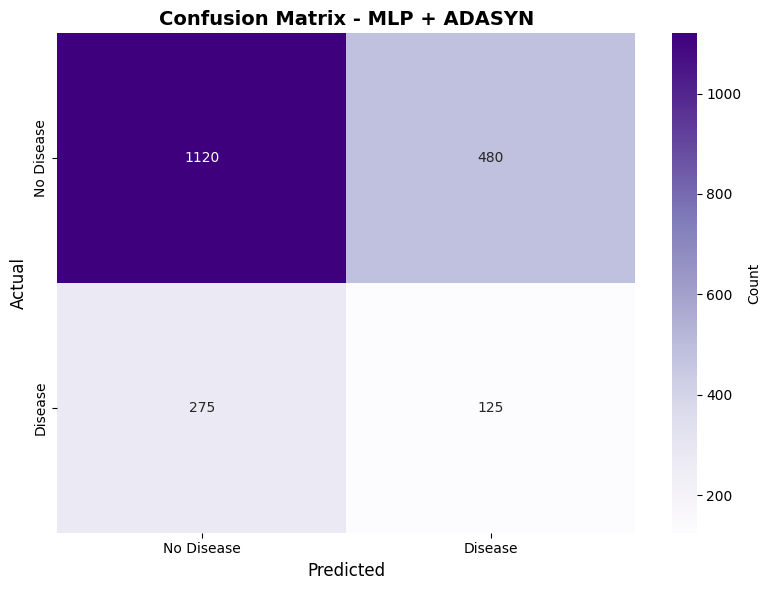


ADASYN RESULTS SUMMARY
Model               : MLP
Sampling            : ADASYN
CV_Accuracy         : 0.4846
CV_Std              : 0.1364
Best_Fold           : 5
Best_Fold_Val_Acc   : 0.6356
Test_Accuracy       : 0.6225
Precision           : 0.2066
Recall              : 0.3125
F1_Score            : 0.2488
ROC_AUC             : 0.5048
✓ Saved best fold model: mlp/models/MLP_adasyn_bestfold.h5
✓ Saved: mlp/models/adasyn_sampler_mlp.pkl


In [5]:
from imblearn.over_sampling import ADASYN

print("-" * 30)
print('MLP + ADASYN')
print("-" * 30)

# Initialize ADASYN
adasyn = ADASYN(random_state=42, n_neighbors=5)

# Apply ADASYN to training data
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train.values.ravel())

print(f"Original training set size: {len(X_train)}")
print(f"After ADASYN training set size: {len(X_train_adasyn)}")
print(f"Original class distribution: {dict(pd.Series(y_train.values.ravel()).value_counts())}")
print(f"After ADASYN class distribution: {dict(pd.Series(y_train_adasyn).value_counts())}")
print("-" * 30)

# Create model
mlp_adasyn = create_mlp_model(X_train.shape[1])

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

print("\n" + "-" * 30)
print("Training MLP with ADASYN...")
print("-" * 30)

# Cross-validation with ADASYN
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
cv_models = []

print("\n" + "-" * 30)
print("Performing 5-Fold Cross-Validation with ADASYN...")
print("-" * 30)

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel())):
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    try:
        # Apply ADASYN
        X_train_fold_adasyn, y_train_fold_adasyn = adasyn.fit_resample(X_train_fold, y_train_fold)
        
        # Create and train model
        model_fold = create_mlp_model(X_train.shape[1])
        model_fold.fit(
            X_train_fold_adasyn, y_train_fold_adasyn,
            validation_data=(X_val_fold, y_val_fold),
            epochs=100,
            batch_size=32,
            callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
            verbose=0
        )
        
        # Evaluate
        _, accuracy, _, _, _ = model_fold.evaluate(X_val_fold, y_val_fold, verbose=0)
        cv_scores.append(accuracy)
        cv_models.append(model_fold)
        print(f"Fold {fold+1}: {accuracy:.4f}  ({accuracy*100:.2f}%)")
    except ValueError as e:
        print(f"Warning in fold {fold+1}: {e}")
        continue

print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print("-" * 30)

# Select best model from CV
if len(cv_models) > 0:
    best_fold_idx = np.argmax(cv_scores)
    mlp_adasyn = cv_models[best_fold_idx]
    print(f"\n✓ Selected Best Model from Fold {best_fold_idx+1} (Accuracy: {cv_scores[best_fold_idx]:.4f})")
else:
    # Fallback to full training if CV failed
    mlp_adasyn = create_mlp_model(X_train.shape[1])
    mlp_adasyn.fit(X_train_adasyn, y_train_adasyn, validation_split=0.2, epochs=100, batch_size=32, 
                   callbacks=[early_stopping, reduce_lr], verbose=0)
    best_fold_idx = 0

# Predictions using best CV model
y_pred_proba = mlp_adasyn.predict(X_test, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# Test set performance
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n" + "=" * 50)
print("TEST SET PERFORMANCE (ADASYN)")
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("=" * 50)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['No Disease', 'Disease'], 
            yticklabels=['No Disease', 'Disease'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - MLP + ADASYN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary dictionary
mlp_adasyn_results = {
    'Model': 'MLP',
    'Sampling': 'ADASYN',
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Best_Fold': best_fold_idx + 1,
    'Best_Fold_Val_Acc': cv_scores[best_fold_idx] if len(cv_scores) > 0 else 0,
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc
}

print("\n" + "=" * 50)
print("ADASYN RESULTS SUMMARY")
print("=" * 50)
for key, value in mlp_adasyn_results.items():
    if isinstance(value, float):
        print(f"{key:20s}: {value:.4f}")
    else:
        print(f"{key:20s}: {value}")
print("=" * 50)

# Save best fold model
mlp_adasyn.save('mlp/models/MLP_adasyn_bestfold.h5')
joblib.dump(adasyn, 'mlp/models/adasyn_sampler_mlp.pkl')
print(f"✓ Saved best fold model: mlp/models/MLP_adasyn_bestfold.h5")
print("✓ Saved: mlp/models/adasyn_sampler_mlp.pkl")

------------------------------
MLP + RandomUnderSampler
------------------------------
Original training set size: 8000
After RUS training set size: 3200
Original class distribution: {0: np.int64(6400), 1: np.int64(1600)}
After RUS class distribution: {0: np.int64(1600), 1: np.int64(1600)}
------------------------------



------------------------------
Training MLP with RUS...
------------------------------

------------------------------
Performing 5-Fold Cross-Validation with RUS...
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/tanananyathongkum/Jenny/Project/Heart 

Fold 1: 0.7019  (70.19%)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

Fold 3: 0.5038  (50.38%)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 4: 0.5163  (51.63%)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 5: 0.7694  (76.94%)
------------------------------
>> Average CV Accuracy: 0.6460 (± 0.1132)
------------------------------

✓ Selected Best Model from Fold 5 (Accuracy: 0.7694)

TEST SET PERFORMANCE (RUS)
Accuracy:  0.7745
Precision: 0.2069
Recall:    0.0450
F1-Score:  0.0739
ROC-AUC:   0.5247

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.80      0.96      0.87      1600
     Disease       0.21      0.04      0.07       400

    accuracy                           0.77      2000
   macro avg       0.50      0.50      0.47      2000
weighted avg       0.68      0.77      0.71      2000



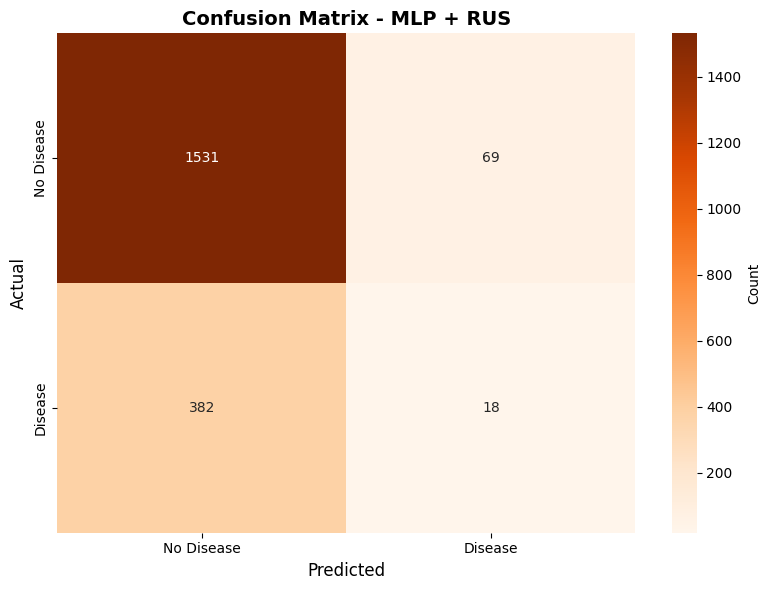


RUS RESULTS SUMMARY
Model               : MLP
Sampling            : RandomUnderSampler
CV_Accuracy         : 0.6460
CV_Std              : 0.1132
Best_Fold           : 5
Best_Fold_Val_Acc   : 0.7694
Test_Accuracy       : 0.7745
Precision           : 0.2069
Recall              : 0.0450
F1_Score            : 0.0739
ROC_AUC             : 0.5247
✓ Saved best fold model: mlp/models/MLP_rus_bestfold.h5
✓ Saved: mlp/models/rus_sampler_mlp.pkl


In [6]:
from imblearn.under_sampling import RandomUnderSampler

print("-" * 30)
print('MLP + RandomUnderSampler')
print("-" * 30)

# Initialize RUS
rus = RandomUnderSampler(random_state=42)

# Apply RUS to training data
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train.values.ravel())

print(f"Original training set size: {len(X_train)}")
print(f"After RUS training set size: {len(X_train_rus)}")
print(f"Original class distribution: {dict(pd.Series(y_train.values.ravel()).value_counts())}")
print(f"After RUS class distribution: {dict(pd.Series(y_train_rus).value_counts())}")
print("-" * 30)

# Create model
mlp_rus = create_mlp_model(X_train.shape[1])

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

print("\n" + "-" * 30)
print("Training MLP with RUS...")
print("-" * 30)

# Cross-validation with RUS
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
cv_models = []

print("\n" + "-" * 30)
print("Performing 5-Fold Cross-Validation with RUS...")
print("-" * 30)

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel())):
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    # Apply RUS
    X_train_fold_rus, y_train_fold_rus = rus.fit_resample(X_train_fold, y_train_fold)
    
    # Create and train model
    model_fold = create_mlp_model(X_train.shape[1])
    model_fold.fit(
        X_train_fold_rus, y_train_fold_rus,
        validation_data=(X_val_fold, y_val_fold),
        epochs=100,
        batch_size=32,
        callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
        verbose=0
    )
    
    # Evaluate
    _, accuracy, _, _, _ = model_fold.evaluate(X_val_fold, y_val_fold, verbose=0)
    cv_scores.append(accuracy)
    cv_models.append(model_fold)
    print(f"Fold {fold+1}: {accuracy:.4f}  ({accuracy*100:.2f}%)")

print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print("-" * 30)

# Select best model from CV
best_fold_idx = np.argmax(cv_scores)
mlp_rus = cv_models[best_fold_idx]
print(f"\n✓ Selected Best Model from Fold {best_fold_idx+1} (Accuracy: {cv_scores[best_fold_idx]:.4f})")

# Predictions using best CV model
y_pred_proba = mlp_rus.predict(X_test, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# Test set performance
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n" + "=" * 50)
print("TEST SET PERFORMANCE (RUS)")
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("=" * 50)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['No Disease', 'Disease'], 
            yticklabels=['No Disease', 'Disease'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - MLP + RUS', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary dictionary
mlp_rus_results = {
    'Model': 'MLP',
    'Sampling': 'RandomUnderSampler',
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Best_Fold': best_fold_idx + 1,
    'Best_Fold_Val_Acc': cv_scores[best_fold_idx],
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc
}

print("\n" + "=" * 50)
print("RUS RESULTS SUMMARY")
print("=" * 50)
for key, value in mlp_rus_results.items():
    if isinstance(value, float):
        print(f"{key:20s}: {value:.4f}")
    else:
        print(f"{key:20s}: {value}")
print("=" * 50)

# Save best fold model
mlp_rus.save('mlp/models/MLP_rus_bestfold.h5')
joblib.dump(rus, 'mlp/models/rus_sampler_mlp.pkl')
print(f"✓ Saved best fold model: mlp/models/MLP_rus_bestfold.h5")
print("✓ Saved: mlp/models/rus_sampler_mlp.pkl")

------------------------------
MLP + NearMiss
------------------------------
Resampling with NearMiss...


Original size: 8000
After NearMiss size: 3200
------------------------------
Performing Cross-Validation...


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 1: 0.7188


Fold 2: 0.7359


...


Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.



Epoch 16: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.


Epoch 16: early stopping


Restoring model weights from the end of the best epoch: 1.



TEST SET PERFORMANCE (NearMiss)
Accuracy:  0.7640
Precision: 0.2273
Recall:    0.0750
F1-Score:  0.1128
ROC-AUC:   0.4950


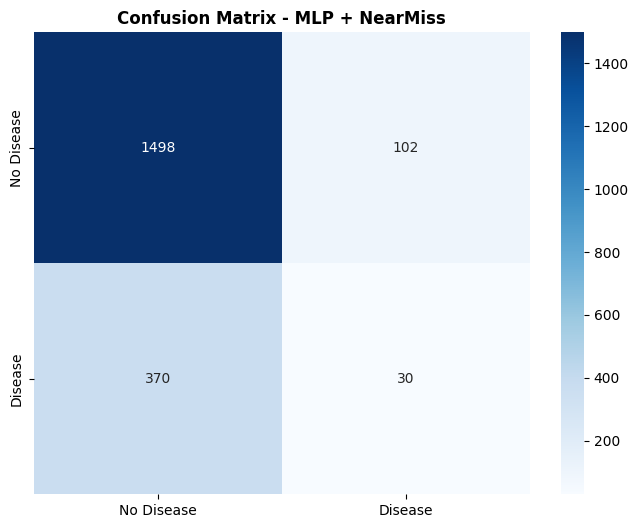

✓ Saved models


In [7]:
from imblearn.under_sampling import NearMiss

print("-" * 30)
print('MLP + NearMiss')
print("-" * 30)

# --- 1. Prepare Data as Numpy Arrays ---
X_train_np = X_train.values if hasattr(X_train, 'values') else X_train
y_train_np = y_train.values.ravel() if hasattr(y_train, 'values') else y_train
X_test_np = X_test.values if hasattr(X_test, 'values') else X_test
y_test_np = y_test.values.ravel() if hasattr(y_test, 'values') else y_test

# --- 2. Apply NearMiss ---
nm = NearMiss(version=2)
print("Resampling with NearMiss...")
X_train_nm, y_train_nm = nm.fit_resample(X_train_np, y_train_np)

print(f"Original size: {len(X_train_np)}")
print(f"After NearMiss size: {len(X_train_nm)}")
print("-" * 30)

# --- 3. Cross-Validation ---
cv_scores = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Performing Cross-Validation...")
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_nm, y_train_nm), 1):
    X_cv_train, X_cv_val = X_train_nm[train_idx], X_train_nm[val_idx]
    y_cv_train, y_cv_val = y_train_nm[train_idx], y_train_nm[val_idx]
    
    # Create & Train
    model_fold = create_mlp_model(X_train.shape[1])
    model_fold.fit(
        X_cv_train, y_cv_train,
        validation_data=(X_cv_val, y_cv_val),
        epochs=50, batch_size=32,
        callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
        verbose=0
    )
    
    # Evaluate (Index 1 is accuracy)
    eval_res = model_fold.evaluate(X_cv_val, y_cv_val, verbose=0)
    cv_scores.append(eval_res[1])
    print(f"Fold {fold}: {eval_res[1]:.4f}")

print(f">> Average CV Accuracy: {np.mean(cv_scores):.4f}")
print("-" * 30)

# --- 4. Full Training ---
print("Training MLP with NearMiss (Full)...")
mlp_nm = create_mlp_model(X_train.shape[1])
history_nm = mlp_nm.fit(
    X_train_nm, y_train_nm,
    validation_split=0.2,
    epochs=100, batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=0
)

# --- 5. Evaluation ---
eval_res = mlp_nm.evaluate(X_test_np, y_test_np, verbose=0)
test_accuracy = eval_res[1]

y_pred_proba = mlp_nm.predict(X_test_np, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

test_precision = precision_score(y_test_np, y_pred)
test_recall = recall_score(y_test_np, y_pred)
test_f1 = f1_score(y_test_np, y_pred)
test_roc_auc = roc_auc_score(y_test_np, y_pred_proba)

# Show Results
print("\n" + "=" * 50)
print("TEST SET PERFORMANCE (NearMiss)")
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("=" * 50)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test_np, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix - MLP + NearMiss', fontweight='bold')
plt.show()

# Save Results
mlp_nearmiss_results = {
    'Model': 'MLP', 'Sampling': 'NearMiss',
    'CV_Accuracy': np.mean(cv_scores), 'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy, 'Precision': test_precision,
    'Recall': test_recall, 'F1_Score': test_f1, 'ROC_AUC': test_roc_auc
}

mlp_nm.save('mlp/models/MLP_nearmiss.h5')
joblib.dump(nm, 'mlp/models/nearmiss_sampler_mlp.pkl')
print("✓ Saved models")

------------------------------
MLP + Cluster Centroids
------------------------------
Resampling... (This may take a while ⏳)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Original size: 8000
After CC size: 3200
------------------------------
Performing Cross-Validation...


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 1: 0.7297


...


Epoch 16: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.


Epoch 16: early stopping


Restoring model weights from the end of the best epoch: 1.



TEST SET PERFORMANCE (Cluster Centroids)
Accuracy:  0.8000
Precision: 0.0000
Recall:    0.0000
F1-Score:  0.0000
ROC-AUC:   0.4888


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


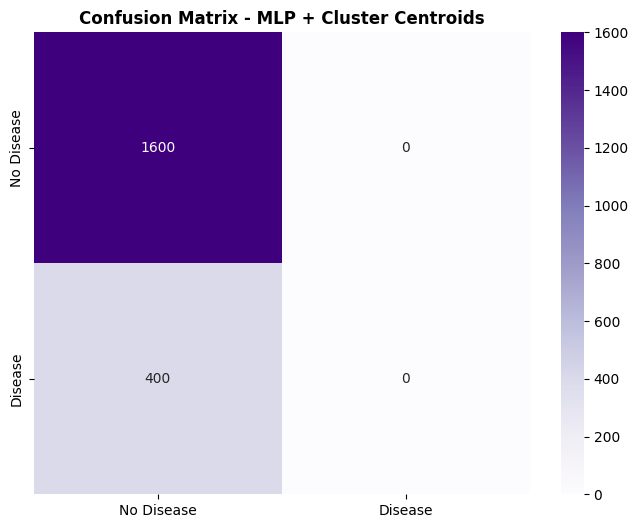

✓ Saved models


In [8]:
from imblearn.under_sampling import ClusterCentroids

print("-" * 30)
print('MLP + Cluster Centroids')
print("-" * 30)

# --- 1. Apply Cluster Centroids ---
cc = ClusterCentroids(random_state=42)
print("Resampling... (This may take a while ⏳)")
X_train_cc, y_train_cc = cc.fit_resample(X_train_np, y_train_np)

print(f"Original size: {len(X_train_np)}")
print(f"After CC size: {len(X_train_cc)}")
print("-" * 30)

# --- 2. Cross-Validation ---
cv_scores = []
print("Performing Cross-Validation...")
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_cc, y_train_cc), 1):
    X_cv_train, X_cv_val = X_train_cc[train_idx], X_train_cc[val_idx]
    y_cv_train, y_cv_val = y_train_cc[train_idx], y_train_cc[val_idx]
    
    model_fold = create_mlp_model(X_train.shape[1])
    model_fold.fit(
        X_cv_train, y_cv_train,
        validation_data=(X_cv_val, y_cv_val),
        epochs=50, batch_size=32,
        callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
        verbose=0
    )
    eval_res = model_fold.evaluate(X_cv_val, y_cv_val, verbose=0)
    cv_scores.append(eval_res[1])
    print(f"Fold {fold}: {eval_res[1]:.4f}")

print(f">> Average CV Accuracy: {np.mean(cv_scores):.4f}")
print("-" * 30)

# --- 3. Full Training ---
print("Training MLP with Cluster Centroids (Full)...")
mlp_cc = create_mlp_model(X_train.shape[1])
history_cc = mlp_cc.fit(
    X_train_cc, y_train_cc,
    validation_split=0.2,
    epochs=100, batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=0
)

# --- 4. Evaluation ---
eval_res = mlp_cc.evaluate(X_test_np, y_test_np, verbose=0)
test_accuracy = eval_res[1]

y_pred_proba = mlp_cc.predict(X_test_np, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

test_precision = precision_score(y_test_np, y_pred)
test_recall = recall_score(y_test_np, y_pred)
test_f1 = f1_score(y_test_np, y_pred)
test_roc_auc = roc_auc_score(y_test_np, y_pred_proba)

# Show Results
print("\n" + "=" * 50)
print("TEST SET PERFORMANCE (Cluster Centroids)")
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("=" * 50)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test_np, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix - MLP + Cluster Centroids', fontweight='bold')
plt.show()

# Save Results
mlp_cc_results = {
    'Model': 'MLP', 'Sampling': 'ClusterCentroids',
    'CV_Accuracy': np.mean(cv_scores), 'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy, 'Precision': test_precision,
    'Recall': test_recall, 'F1_Score': test_f1, 'ROC_AUC': test_roc_auc
}

mlp_cc.save('mlp/models/MLP_cc.h5')
joblib.dump(cc, 'mlp/models/cc_sampler_mlp.pkl')
print("✓ Saved models")

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

------------------------------
MLP + SMOTETomek
------------------------------
Original training set size: 8000
After SMOTETomek training set size: 12772
Original class distribution: {0: np.int64(6400), 1: np.int64(1600)}
After SMOTETomek class distribution: {0: np.int64(6386), 1: np.int64(6386)}
------------------------------

------------------------------
Performing 5-Fold Cross-Validation with SMOTETomek...
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 1: 0.6538  (65.38%)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

...

Fold 3: 0.6125  (61.25%)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

Fold 4: 0.3338  (33.38%)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

Fold 5: 0.6350  (63.50%)
------------------------------
>> Average CV Accuracy: 0.5279 (± 0.1322)
------------------------------

✓ Selected Best Model from Fold 1 (Accuracy: 0.6538)

TEST SET PERFORMANCE (SMOTETomek)
Accuracy:  0.6390
Precision: 0.2051
Recall:    0.2800
F1-Score:  0.2368
ROC-AUC:   0.4967

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.80      0.73      0.76      1600
     Disease       0.21      0.28      0.24       400

    accuracy                           0.64      2000
   macro avg       0.50      0.50      0.50      2000
weighted avg       0.68      0.64      0.66      2000



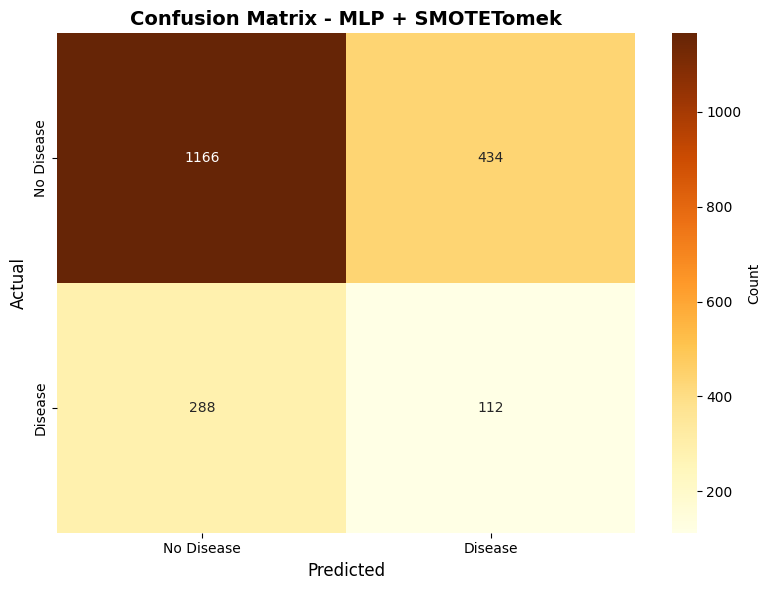


SMOTETomek RESULTS SUMMARY
Model               : MLP
Sampling            : SMOTETomek
CV_Accuracy         : 0.5279
CV_Std              : 0.1322
Best_Fold           : 1
Best_Fold_Val_Acc   : 0.6538
Test_Accuracy       : 0.6390
Precision           : 0.2051
Recall              : 0.2800
F1_Score            : 0.2368
ROC_AUC             : 0.4967
✓ Saved best fold model: mlp/models/MLP_smote_tomek_bestfold.h5
✓ Saved: mlp/models/smote_tomek_sampler_mlp.pkl


In [9]:
from imblearn.combine import SMOTETomek

print("-" * 30)
print('MLP + SMOTETomek')
print("-" * 30)

# Initialize SMOTETomek
smote_tomek = SMOTETomek(random_state=42)

# Apply SMOTETomek to training data
X_train_smote_tomek, y_train_smote_tomek = smote_tomek.fit_resample(X_train, y_train.values.ravel())

print(f"Original training set size: {len(X_train)}")
print(f"After SMOTETomek training set size: {len(X_train_smote_tomek)}")
print(f"Original class distribution: {dict(pd.Series(y_train.values.ravel()).value_counts())}")
print(f"After SMOTETomek class distribution: {dict(pd.Series(y_train_smote_tomek).value_counts())}")
print("-" * 30)

# Create model
mlp_smote_tomek = create_mlp_model(X_train.shape[1])

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

# Cross-validation with SMOTETomek
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
cv_models = []

print("\n" + "-" * 30)
print("Performing 5-Fold Cross-Validation with SMOTETomek...")
print("-" * 30)

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel())):
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    # Apply SMOTETomek
    X_train_fold_smote_tomek, y_train_fold_smote_tomek = smote_tomek.fit_resample(X_train_fold, y_train_fold)
    
    # Create and train model
    model_fold = create_mlp_model(X_train.shape[1])
    model_fold.fit(
        X_train_fold_smote_tomek, y_train_fold_smote_tomek,
        validation_data=(X_val_fold, y_val_fold),
        epochs=100,
        batch_size=32,
        callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
        verbose=0
    )
    
    # Evaluate
    _, accuracy, _, _, _ = model_fold.evaluate(X_val_fold, y_val_fold, verbose=0)
    cv_scores.append(accuracy)
    cv_models.append(model_fold)
    print(f"Fold {fold+1}: {accuracy:.4f}  ({accuracy*100:.2f}%)")

print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print("-" * 30)

# Select best model from CV
best_fold_idx = np.argmax(cv_scores)
mlp_smote_tomek = cv_models[best_fold_idx]
print(f"\n✓ Selected Best Model from Fold {best_fold_idx+1} (Accuracy: {cv_scores[best_fold_idx]:.4f})")

# Predictions using best CV model
y_pred_proba = mlp_smote_tomek.predict(X_test, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# Test set performance
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n" + "=" * 50)
print("TEST SET PERFORMANCE (SMOTETomek)")
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("=" * 50)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='YlOrBr', 
            xticklabels=['No Disease', 'Disease'], 
            yticklabels=['No Disease', 'Disease'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - MLP + SMOTETomek', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary dictionary
mlp_smote_tomek_results = {
    'Model': 'MLP',
    'Sampling': 'SMOTETomek',
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Best_Fold': best_fold_idx + 1,
    'Best_Fold_Val_Acc': cv_scores[best_fold_idx],
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc
}

print("\n" + "=" * 50)
print("SMOTETomek RESULTS SUMMARY")
print("=" * 50)
for key, value in mlp_smote_tomek_results.items():
    if isinstance(value, float):
        print(f"{key:20s}: {value:.4f}")
    else:
        print(f"{key:20s}: {value}")
print("=" * 50)

# Save best fold model
mlp_smote_tomek.save('mlp/models/MLP_smote_tomek_bestfold.h5')
joblib.dump(smote_tomek, 'mlp/models/smote_tomek_sampler_mlp.pkl')
print(f"✓ Saved best fold model: mlp/models/MLP_smote_tomek_bestfold.h5")
print("✓ Saved: mlp/models/smote_tomek_sampler_mlp.pkl")

------------------------------
MLP + SMOTEENN
------------------------------


Original training set size: 8000
After SMOTEENN training set size: 8022
Original class distribution: {0: np.int64(6400), 1: np.int64(1600)}
After SMOTEENN class distribution: {1: np.int64(6043), 0: np.int64(1979)}
------------------------------

------------------------------
Performing 5-Fold Cross-Validation with SMOTEENN...
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 1: 0.2000  (20.00%)


...

Fold 3: 0.2056  (20.56%)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

Fold 4: 0.2000  (20.00%)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

Fold 5: 0.2000  (20.00%)
------------------------------
>> Average CV Accuracy: 0.2011 (± 0.0022)
------------------------------

✓ Selected Best Model from Fold 3 (Accuracy: 0.2056)

TEST SET PERFORMANCE (SMOTEENN)
Accuracy:  0.2215
Precision: 0.2013
Recall:    0.9750
F1-Score:  0.3338
ROC-AUC:   0.4881

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.84      0.03      0.06      1600
     Disease       0.20      0.97      0.33       400

    accuracy                           0.22      2000
   macro avg       0.52      0.50      0.20      2000
weighted avg       0.71      0.22      0.12      2000



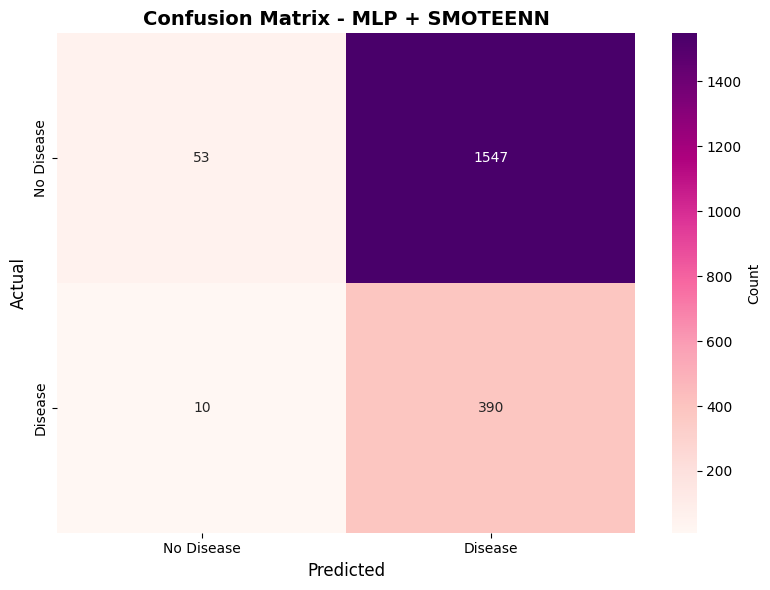


SMOTEENN RESULTS SUMMARY
Model               : MLP
Sampling            : SMOTEENN
CV_Accuracy         : 0.2011
CV_Std              : 0.0022
Best_Fold           : 3
Best_Fold_Val_Acc   : 0.2056
Test_Accuracy       : 0.2215
Precision           : 0.2013
Recall              : 0.9750
F1_Score            : 0.3338
ROC_AUC             : 0.4881
✓ Saved best fold model: mlp/models/MLP_smote_enn_bestfold.h5
✓ Saved: mlp/models/smote_enn_sampler_mlp.pkl


In [10]:
from imblearn.combine import SMOTEENN

print("-" * 30)
print('MLP + SMOTEENN')
print("-" * 30)

# Initialize SMOTEENN
smote_enn = SMOTEENN(random_state=42)

# Apply SMOTEENN to training data
X_train_smote_enn, y_train_smote_enn = smote_enn.fit_resample(X_train, y_train.values.ravel())

print(f"Original training set size: {len(X_train)}")
print(f"After SMOTEENN training set size: {len(X_train_smote_enn)}")
print(f"Original class distribution: {dict(pd.Series(y_train.values.ravel()).value_counts())}")
print(f"After SMOTEENN class distribution: {dict(pd.Series(y_train_smote_enn).value_counts())}")
print("-" * 30)

# Create model
mlp_smote_enn = create_mlp_model(X_train.shape[1])

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

# Cross-validation with SMOTEENN
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
cv_models = []

print("\n" + "-" * 30)
print("Performing 5-Fold Cross-Validation with SMOTEENN...")
print("-" * 30)

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel())):
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    # Apply SMOTEENN
    X_train_fold_smote_enn, y_train_fold_smote_enn = smote_enn.fit_resample(X_train_fold, y_train_fold)
    
    # Create and train model
    model_fold = create_mlp_model(X_train.shape[1])
    model_fold.fit(
        X_train_fold_smote_enn, y_train_fold_smote_enn,
        validation_data=(X_val_fold, y_val_fold),
        epochs=100,
        batch_size=32,
        callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
        verbose=0
    )
    
    # Evaluate
    _, accuracy, _, _, _ = model_fold.evaluate(X_val_fold, y_val_fold, verbose=0)
    cv_scores.append(accuracy)
    cv_models.append(model_fold)
    print(f"Fold {fold+1}: {accuracy:.4f}  ({accuracy*100:.2f}%)")

print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print("-" * 30)

# Select best model from CV
best_fold_idx = np.argmax(cv_scores)
mlp_smote_enn = cv_models[best_fold_idx]
print(f"\n✓ Selected Best Model from Fold {best_fold_idx+1} (Accuracy: {cv_scores[best_fold_idx]:.4f})")

# Predictions using best CV model
y_pred_proba = mlp_smote_enn.predict(X_test, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# Test set performance
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n" + "=" * 50)
print("TEST SET PERFORMANCE (SMOTEENN)")
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("=" * 50)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='RdPu', 
            xticklabels=['No Disease', 'Disease'], 
            yticklabels=['No Disease', 'Disease'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - MLP + SMOTEENN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary dictionary
mlp_smote_enn_results = {
    'Model': 'MLP',
    'Sampling': 'SMOTEENN',
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Best_Fold': best_fold_idx + 1,
    'Best_Fold_Val_Acc': cv_scores[best_fold_idx],
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc
}

print("\n" + "=" * 50)
print("SMOTEENN RESULTS SUMMARY")
print("=" * 50)
for key, value in mlp_smote_enn_results.items():
    if isinstance(value, float):
        print(f"{key:20s}: {value:.4f}")
    else:
        print(f"{key:20s}: {value}")
print("=" * 50)

# Save best fold model
mlp_smote_enn.save('mlp/models/MLP_smote_enn_bestfold.h5')
joblib.dump(smote_enn, 'mlp/models/smote_enn_sampler_mlp.pkl')
print(f"✓ Saved best fold model: mlp/models/MLP_smote_enn_bestfold.h5")
print("✓ Saved: mlp/models/smote_enn_sampler_mlp.pkl")

------------------------------
MLP + ADASYN + Tomek Links
------------------------------
Resampling with ADASYN + Tomek...


Original size: 8000
After ADASYN+Tomek size: 12821
------------------------------
Performing Cross-Validation...


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

Fold 1: 0.3069


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the 

...


Epoch 86: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.



Epoch 91: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.


Epoch 91: early stopping


Restoring model weights from the end of the best epoch: 76.



TEST SET PERFORMANCE (ADASYN + Tomek)
Accuracy:  0.6785
Precision: 0.2128
Recall:    0.2250
F1-Score:  0.2187
ROC-AUC:   0.5004


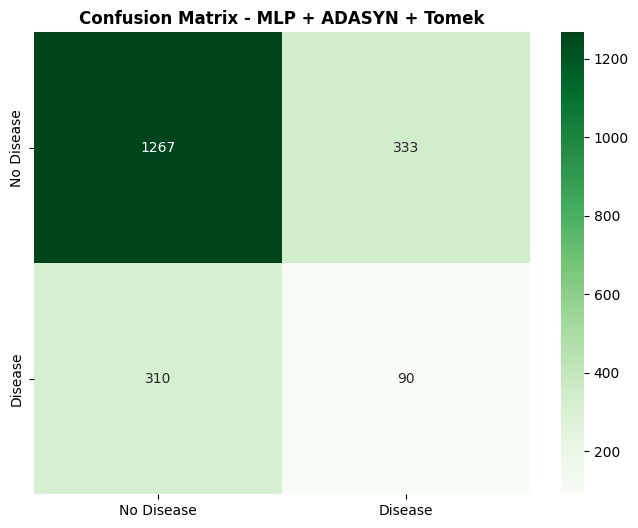

✓ Saved models


In [11]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import ADASYN
from imblearn.under_sampling import TomekLinks

print("-" * 30)
print('MLP + ADASYN + Tomek Links')
print("-" * 30)

# --- 1. Apply ADASYN + Tomek ---
pipe_at = ImbPipeline([
    ('adasyn', ADASYN(random_state=42)),
    ('tomek', TomekLinks())
])
print("Resampling with ADASYN + Tomek...")
X_train_at, y_train_at = pipe_at.fit_resample(X_train_np, y_train_np)

print(f"Original size: {len(X_train_np)}")
print(f"After ADASYN+Tomek size: {len(X_train_at)}")
print("-" * 30)

# --- 2. Cross-Validation ---
cv_scores = []
print("Performing Cross-Validation...")
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_np, y_train_np), 1):
    X_train_fold, X_val_fold = X_train_np[train_idx], X_train_np[val_idx]
    y_train_fold, y_val_fold = y_train_np[train_idx], y_train_np[val_idx]
    
    # Resample only training fold
    X_train_res, y_train_res = pipe_at.fit_resample(X_train_fold, y_train_fold)
    
    model_fold = create_mlp_model(X_train.shape[1])
    model_fold.fit(
        X_train_res, y_train_res,
        validation_data=(X_val_fold, y_val_fold),
        epochs=50, batch_size=32,
        callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
        verbose=0
    )
    eval_res = model_fold.evaluate(X_val_fold, y_val_fold, verbose=0)
    cv_scores.append(eval_res[1])
    print(f"Fold {fold}: {eval_res[1]:.4f}")

print(f">> Average CV Accuracy: {np.mean(cv_scores):.4f}")
print("-" * 30)

# --- 3. Full Training ---
print("Training MLP with ADASYN+Tomek (Full)...")
mlp_at = create_mlp_model(X_train.shape[1])
history_at = mlp_at.fit(
    X_train_at, y_train_at,
    validation_split=0.2,
    epochs=100, batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=0
)

# --- 4. Evaluation ---
eval_res = mlp_at.evaluate(X_test_np, y_test_np, verbose=0)
test_accuracy = eval_res[1]

y_pred_proba = mlp_at.predict(X_test_np, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

test_precision = precision_score(y_test_np, y_pred)
test_recall = recall_score(y_test_np, y_pred)
test_f1 = f1_score(y_test_np, y_pred)
test_roc_auc = roc_auc_score(y_test_np, y_pred_proba)

# Show Results
print("\n" + "=" * 50)
print("TEST SET PERFORMANCE (ADASYN + Tomek)")
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("=" * 50)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test_np, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix - MLP + ADASYN + Tomek', fontweight='bold')
plt.show()

# Save Results
mlp_adasyn_tomek_results = {
    'Model': 'MLP', 'Sampling': 'ADASYN+Tomek',
    'CV_Accuracy': np.mean(cv_scores), 'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy, 'Precision': test_precision,
    'Recall': test_recall, 'F1_Score': test_f1, 'ROC_AUC': test_roc_auc
}

mlp_at.save('mlp/models/MLP_adasyn_tomek.h5')
joblib.dump(pipe_at, 'mlp/models/adasyn_tomek_sampler_mlp.pkl')
print("✓ Saved models")

------------------------------
MLP + BorderlineSMOTE + Tomek Links
------------------------------
Resampling with Borderline+Tomek...
Original size: 8000
After Borderline+Tomek size: 12743
------------------------------
Performing Cross-Validation...


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

Fold 1: 0.4444


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the 

Fold 2: 0.6731


...


Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.



Epoch 49: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.



Epoch 76: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.


Restoring model weights from the end of the best epoch: 99.



TEST SET PERFORMANCE (Borderline + Tomek)
Accuracy:  0.6620
Precision: 0.1864
Recall:    0.2050
F1-Score:  0.1952
ROC-AUC:   0.4892


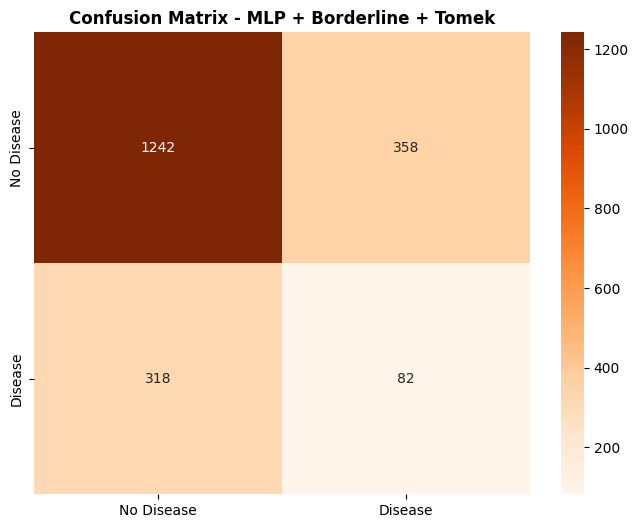

✓ Saved models


In [12]:
from imblearn.over_sampling import BorderlineSMOTE

print("-" * 30)
print('MLP + BorderlineSMOTE + Tomek Links')
print("-" * 30)

# --- 1. Apply Borderline+Tomek ---
pipe_bt = ImbPipeline([
    ('borderline', BorderlineSMOTE(random_state=42, kind='borderline-2')),
    ('tomek', TomekLinks())
])
print("Resampling with Borderline+Tomek...")
X_train_bt, y_train_bt = pipe_bt.fit_resample(X_train_np, y_train_np)

print(f"Original size: {len(X_train_np)}")
print(f"After Borderline+Tomek size: {len(X_train_bt)}")
print("-" * 30)

# --- 2. Cross-Validation ---
cv_scores = []
print("Performing Cross-Validation...")
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_np, y_train_np), 1):
    X_train_fold, X_val_fold = X_train_np[train_idx], X_train_np[val_idx]
    y_train_fold, y_val_fold = y_train_np[train_idx], y_train_np[val_idx]
    
    X_train_res, y_train_res = pipe_bt.fit_resample(X_train_fold, y_train_fold)
    
    model_fold = create_mlp_model(X_train.shape[1])
    model_fold.fit(
        X_train_res, y_train_res,
        validation_data=(X_val_fold, y_val_fold),
        epochs=50, batch_size=32,
        callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
        verbose=0
    )
    eval_res = model_fold.evaluate(X_val_fold, y_val_fold, verbose=0)
    cv_scores.append(eval_res[1])
    print(f"Fold {fold}: {eval_res[1]:.4f}")

print(f">> Average CV Accuracy: {np.mean(cv_scores):.4f}")
print("-" * 30)

# --- 3. Full Training ---
print("Training MLP with Borderline+Tomek (Full)...")
mlp_bt = create_mlp_model(X_train.shape[1])
history_bt = mlp_bt.fit(
    X_train_bt, y_train_bt,
    validation_split=0.2,
    epochs=100, batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=0
)

# --- 4. Evaluation ---
eval_res = mlp_bt.evaluate(X_test_np, y_test_np, verbose=0)
test_accuracy = eval_res[1]

y_pred_proba = mlp_bt.predict(X_test_np, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

test_precision = precision_score(y_test_np, y_pred)
test_recall = recall_score(y_test_np, y_pred)
test_f1 = f1_score(y_test_np, y_pred)
test_roc_auc = roc_auc_score(y_test_np, y_pred_proba)

# Show Results
print("\n" + "=" * 50)
print("TEST SET PERFORMANCE (Borderline + Tomek)")
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("=" * 50)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test_np, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix - MLP + Borderline + Tomek', fontweight='bold')
plt.show()

# Save Results
mlp_borderline_tomek_results = {
    'Model': 'MLP', 'Sampling': 'Borderline+Tomek',
    'CV_Accuracy': np.mean(cv_scores), 'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy, 'Precision': test_precision,
    'Recall': test_recall, 'F1_Score': test_f1, 'ROC_AUC': test_roc_auc
}

mlp_bt.save('mlp/models/MLP_borderline_tomek.h5')
joblib.dump(pipe_bt, 'mlp/models/borderline_tomek_sampler_mlp.pkl')
print("✓ Saved models")


MLP - COMPREHENSIVE SUMMARY
Model           Sampling  CV_Accuracy   CV_Std  Best_Fold  Best_Fold_Val_Acc  Test_Accuracy  Precision  Recall  F1_Score  ROC_AUC
  MLP    None (Baseline)     0.800000 0.000000        1.0           0.800000         0.8000   0.000000  0.0000  0.000000 0.471098
  MLP              SMOTE     0.507750 0.124458        5.0           0.661875         0.6550   0.196653  0.2350  0.214123 0.505183
  MLP             ADASYN     0.484625 0.136433        5.0           0.635625         0.6225   0.206612  0.3125  0.248756 0.504773
  MLP RandomUnderSampler     0.646000 0.113151        5.0           0.769375         0.7745   0.206897  0.0450  0.073922 0.524741
  MLP         SMOTETomek     0.527875 0.132226        1.0           0.653750         0.6390   0.205128  0.2800  0.236786 0.496731
  MLP           SMOTEENN     0.201125 0.002250        3.0           0.205625         0.2215   0.201342  0.9750  0.333761 0.488061
  MLP           NearMiss     0.733437 0.014876        NaN    

/var/folders/pb/8b1j14m116723lhg0z_g3nnm0000gn/T/ipykernel_16751/2607600070.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(mlp_df['Sampling'], rotation=45, ha='right')
/var/folders/pb/8b1j14m116723lhg0z_g3nnm0000gn/T/ipykernel_16751/2607600070.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(mlp_df['Sampling'], rotation=45, ha='right')
/var/folders/pb/8b1j14m116723lhg0z_g3nnm0000gn/T/ipykernel_16751/2607600070.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(mlp_df['Sampling'], rotation=45, ha='right')
/var/folders/pb/8b1j14m116723lhg0z_g3nnm0000gn/T/ipykernel_16751/2607600070.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. a

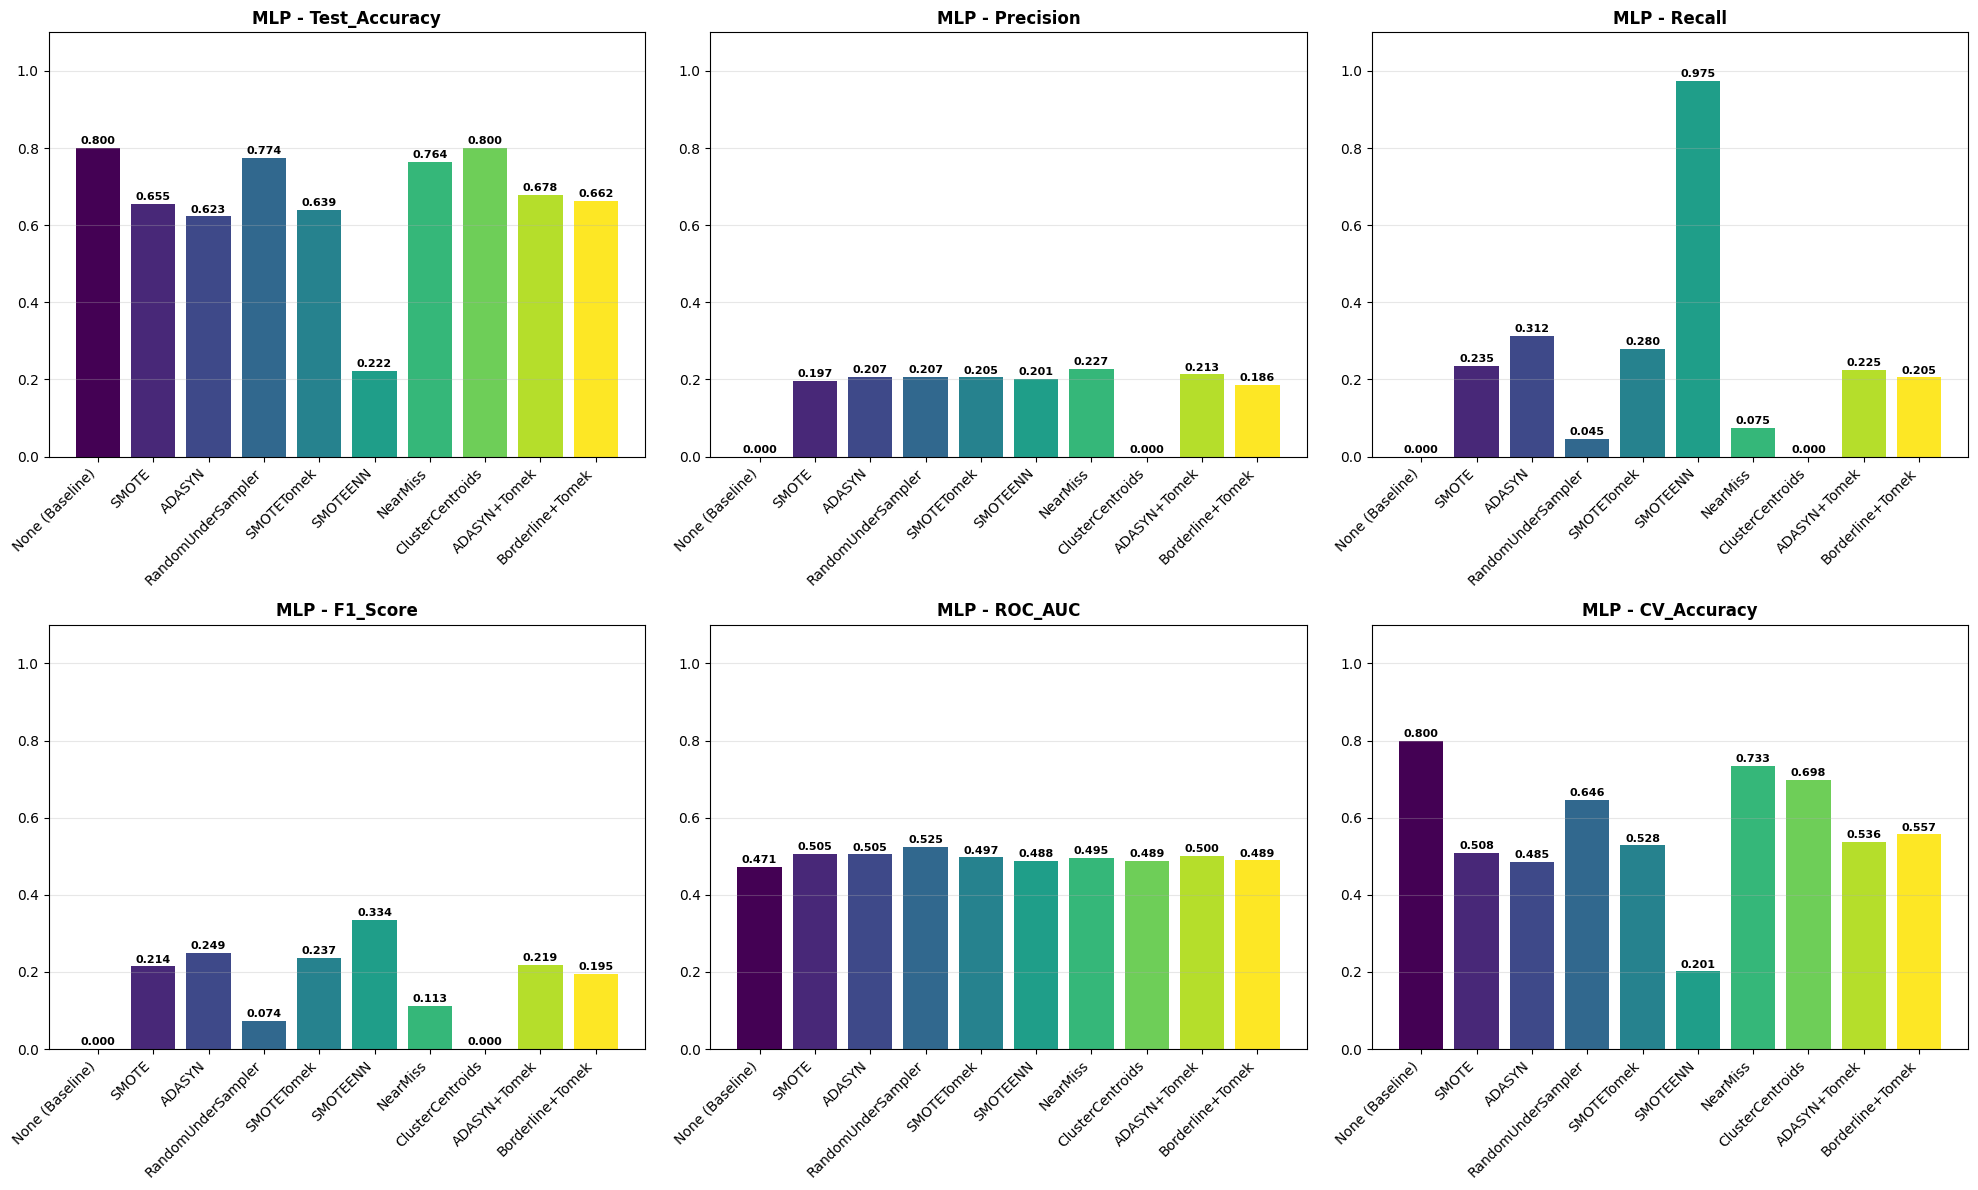


🏆 BEST MLP MODEL
Best by F1-Score: SMOTEENN (0.3338)


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# 1. รวบรวมผลลัพธ์ (เช็คชื่อตัวแปรเก่าให้ครบนะครับ)
mlp_all_results = [
    mlp_baseline_results,
    mlp_smote_results,
    mlp_adasyn_results,
    mlp_rus_results, 
    mlp_smote_tomek_results,
    mlp_smote_enn_results, 
    
    # ของใหม่
    mlp_nearmiss_results,
    mlp_cc_results,
    mlp_adasyn_tomek_results,
    mlp_borderline_tomek_results
]

# 2. สร้าง DataFrame
mlp_df = pd.DataFrame(mlp_all_results)

print("\n" + "=" * 90)
print("MLP - COMPREHENSIVE SUMMARY")
print("=" * 90)
print(mlp_df.to_string(index=False))

# 3. Save CSV
os.makedirs('mlp/models', exist_ok=True)
mlp_df.to_csv('mlp/models/mlp_summary.csv', index=False)
print("✓ Saved summary CSV")

# 4. Visualization
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()
metrics = ['Test_Accuracy', 'Precision', 'Recall', 'F1_Score', 'ROC_AUC', 'CV_Accuracy']
colors = plt.cm.viridis(np.linspace(0, 1, len(mlp_df)))

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    if metric in mlp_df.columns:
        bars = ax.bar(mlp_df['Sampling'], mlp_df[metric], color=colors)
        ax.set_title(f'MLP - {metric}', fontsize=12, fontweight='bold')
        ax.set_xticklabels(mlp_df['Sampling'], rotation=45, ha='right')
        ax.set_ylim([0, 1.1])
        ax.grid(axis='y', alpha=0.3)
        
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01, 
                    f'{bar.get_height():.3f}', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('mlp/models/mlp_comparison_plot.png', dpi=300)
plt.show()

# 5. Best Model Recommendation
print("\n" + "=" * 90)
print("🏆 BEST MLP MODEL")
print("=" * 90)
best_f1_idx = mlp_df['F1_Score'].idxmax()
print(f"Best by F1-Score: {mlp_df.loc[best_f1_idx, 'Sampling']} ({mlp_df.loc[best_f1_idx, 'F1_Score']:.4f})")